# CatBoost Model Development and Evaluation Script

## Modeling Pipeline

- **Baseline Model Development:** A standard CatBoost model was trained using default hyperparameters to establish a performance benchmark.
- **Hyperparameter Optimization:** The baseline model was optimized using ***`Optuna`*** and ***`BayesianSearchCV`***, enabling selection of the most effective hyperparameter configurations.
- **Cross-Validation and Robustness Assessment:** Each model variant was subjected to cross-validation to evaluate stability and generalization performance.
- **Overfitting Analysis:** A detailed comparison between cross-validation metrics and test set results was conducted. Additional metrics, including ***`RMSE ratio`*** and ***`R² gap`***, were computed to quantify overfitting and assess model generalization.

---

## Persisted Artifacts

To ensure reproducibility, transparency, and extendability, the following artifacts have been saved:

- **Optimized Model Performance:** Individual CSV files capturing the performance of each model variant:
    - ***CatBoost (Baseline)***
    - ***CatBoost (Optuna)***
    - ***CatBoost (BayesianSearchCV)***

These files include detailed evaluation metrics for each variant.

- **Best Variation Performance:** A CSV file containing only the metrics of the best-performing model variation, allowing quick reference without reviewing all variants.

- **Summary of Model Performance:** A consolidated CSV file including:
    - Cross-validation results (`CV MSE`, ` MAE`, `CV RMSE`, `CV R² Score`, `CV MAPE`)
    - Test set results (`Test MSE`, `Test MAE`, `Test RMSE`, `Test R² Score`, `Test MAPE`)
    - Overfitting metrics (`R² gap`, `RMSE ratio`)
    - Overfitting status and model generalization

This file is extendable, allowing addition of new model evaluations in the future.

- **Overfitting DataFrame:** An extendable CSV specifically capturing overfitting analysis metrics across all models and variations.

- **Best Model Variation:** The serialized best-performing CatBoost model for deployment or further inference.

Together, these artifacts provide a complete, reproducible record of the modeling process, facilitating model tracking, comparison, and deployment.

## Import Libraries and Root Configuration

In [1]:
""" Configure the utilities module path for imports """
import sys
import os
from pathlib import Path

# get project root as parent of current working directory
project_root = Path(os.getcwd()).parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [2]:
# records and calculations
import pandas as pd
import numpy as np

# avoid minor warnings
import warnings
warnings.filterwarnings('ignore')

# read file path
from pathlib import Path

# visualizations
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error

# catboost model
from catboost import CatBoostRegressor

# optimization
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical

# import helper functions
from utilities import Evaluator, DataHandler, ModelPersister

## Load Dataset and Artifacts

In [3]:
df, x, y = DataHandler.load_dataset("../data/encoded_dataset.csv")
artifacts = DataHandler.load_artifacts("../artifacts/feature-selection", cv_required=True)

In [4]:
# check dataset loading
df.head()

,ItemWeight,MRP,OutletAge,Visibility,IsVisibile,IsGroceryStore,PricePerWeight,ItemType,FatContent_Regular,OutletSize_Medium,OutletSize_Small,LocationType_Tier 2,LocationType_Tier 3,OutletType_Supermarket Type1,OutletType_Supermarket Type2,OutletType_Supermarket Type3,OutletSales
0,9.500,171.3448,26,0.034600,1,0,18.036295,7.369344,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,7.777469
1,18.000,170.5422,23,0.046381,1,0,9.474567,7.338780,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,8.040434
2,17.600,111.7202,28,0.073364,1,0,6.347739,7.294114,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,7.025718
3,8.325,41.6138,23,0.029409,1,0,4.998655,7.369344,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,5.650018
4,12.850,155.5630,28,0.128594,1,0,12.106070,7.372674,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,8.348656


In [5]:
# check input features
x.head()

,ItemWeight,MRP,OutletAge,Visibility,IsVisibile,IsGroceryStore,PricePerWeight,ItemType,FatContent_Regular,OutletSize_Medium,OutletSize_Small,LocationType_Tier 2,LocationType_Tier 3,OutletType_Supermarket Type1,OutletType_Supermarket Type2,OutletType_Supermarket Type3
0,9.500,171.3448,26,0.034600,1,0,18.036295,7.369344,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,18.000,170.5422,23,0.046381,1,0,9.474567,7.338780,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0
2,17.600,111.7202,28,0.073364,1,0,6.347739,7.294114,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,8.325,41.6138,23,0.029409,1,0,4.998655,7.369344,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0
4,12.850,155.5630,28,0.128594,1,0,12.106070,7.372674,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [6]:
# check target feature
y.head()

0    7.777469
1    8.040434
2    7.025718
3    5.650018
4    8.348656
Name: OutletSales, dtype: float64

In [7]:
# load train/test split data
x_train, x_test, y_train, y_test = artifacts['x_train'], artifacts['x_test'], artifacts['y_train'], artifacts['y_test']
cv = artifacts['cv']

# Baseline Modeling

## Train CatBoost Model

In [ ]:
# artifacts for catboost
x_train_cb, x_test_cb, cat_features, cat_indices = DataHandler.prepare_for_catboost(x_train, x_test)

print(f"categorical features: {cat_features}")
print(f"cat indices: {cat_indices}")

categorical features: ['OutletAge', 'IsVisibile', 'IsGroceryStore', 'FatContent_Regular', 'OutletSize_Medium', 'OutletSize_Small', 'LocationType_Tier 2', 'LocationType_Tier 3', 'OutletType_Supermarket Type1', 'OutletType_Supermarket Type2', 'OutletType_Supermarket Type3']
cat indices: [2, 4, 5, 8, 9, 10, 11, 12, 13, 14, 15]


In [9]:
# create baseline model
baseline_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.1,
    depth=6,
    l2_leaf_reg=3.0,
    random_strength=1.0,
    bagging_temperature=1.0,
    random_state=42,
    verbose=False,
    cat_features=cat_indices  # ← KEY: tell CatBoost which are categorical
)

# train baseline mode
baseline_model.fit(x_train_cb, y_train,
                   eval_set=(x_test_cb, y_test),
                   early_stopping_rounds=50,
                   verbose=False
                   )

print(f"Best iteration: {baseline_model.best_iteration_}")

Best iteration: 95


## Apply Model to Make Predication

In [10]:
# baseline prediction on train and test set
y_train_pred_baseline = baseline_model.predict(x_train_cb)
y_test_pred_baseline = baseline_model.predict(x_test_cb)

## Evaluating Model Performance
Calculating Errors for train and test data

In [11]:
# evaluation of train metrics
train_metrics_baseline = Evaluator.calculate_metrics(y_train, y_train_pred_baseline)

# evaluation of test metrics
test_metrics_baseline = Evaluator.calculate_metrics(y_test, y_test_pred_baseline)

In [12]:
# Baseline Model Performance
baseline_perf = Evaluator.performance_table(train_metrics_baseline, test_metrics_baseline)

print("CatBoost - Baseline Modeling Performance")
display(baseline_perf)

CatBoost - Baseline Modeling Performance


,Metrics,Training,Test
0,MSE,0.2565,0.2682
1,MAE,0.3908,0.4002
2,RMSE,0.5065,0.5178
3,R2 Score,0.7506,0.7459
4,MAPE,5.6536,5.8874


# Optuna Optimzation

## Find Best Parameters

In [13]:
# define objective function
def objective(trial):
    params = {
        "iterations": 500,
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "depth": trial.suggest_int("depth", 4, 10),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 0.1, 10, log=True),
        "random_strength": trial.suggest_float("random_strength", 0.5, 5.0),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 10.0),
        "border_count": trial.suggest_int("border_count", 32, 255),
        "random_state": 42,
        "verbose": False,
        "cat_features": cat_indices,
        "loss_function": "RMSE"
    }

    # create model
    model = CatBoostRegressor(**params)

    # fit model
    model.fit(x_train_cb, y_train, eval_set=[(x_train_cb, y_train)], early_stopping_rounds=30, verbose=False)

    # predict & evaluate on TRAIN; Optuna will rank by this
    y_pred = model.predict(x_train_cb)
    rmse = np.sqrt(mean_squared_error(y_train, y_pred))
    
    return rmse

In [14]:
# enable pruning to skip bad trials early
pruner = optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=20)

# create optuna study object
study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=pruner
)

# optuna optimization with hyperparameter tuning
print("🚀 Starting Optuna optimization for CatBoost (30 trials, with pruning)...")
study.optimize(objective, n_trials=30, show_progress_bar=True)

🚀 Starting Optuna optimization for CatBoost (30 trials, with pruning)...


Best trial: 27. Best value: 0.230718: 100%|██████████| 30/30 [17:11<00:00, 34.39s/it]


# Train and Apply Model to Make Prediction

In [15]:
# Build final model with best params
best_params_optuna = study.best_params.copy()

# train optimized model
optuna_model = CatBoostRegressor(**best_params_optuna, random_state=42)
optuna_model.fit(x_train_cb, y_train, eval_set=[(x_test_cb, y_test)], early_stopping_rounds=50, verbose=False)

In [16]:
# apply model to make predictions on train and test set
y_train_pred_optuna = optuna_model.predict(x_train_cb)
y_test_pred_optuna = optuna_model.predict(x_test_cb)

## Evaluating Optimized Model Performance
Calculating Errors for train and test data

In [17]:
# calculate train and test metrics
# return [mse, mae, rmse, r2, mape]
train_metrics_optuna = Evaluator.calculate_metrics(y_train, y_train_pred_optuna)
test_metrics_optuna = Evaluator.calculate_metrics(y_test, y_test_pred_optuna)

In [18]:
# performance table of optuna optimization
optuna_perf = Evaluator.performance_table(train_metrics_optuna, test_metrics_optuna)

print("CatBoost - Optuna Optimized Modeling Performance")
display(optuna_perf)

CatBoost - Optuna Optimized Modeling Performance


,Metrics,Training,Test
0,MSE,0.2432,0.2730
1,MAE,0.3813,0.4029
2,RMSE,0.4931,0.5225
3,R2 Score,0.7636,0.7413
4,MAPE,5.5206,5.9393


#  BayesianSearch Optimzation

## Train BayesianSearch Model

In [19]:
# Parameter space — Bayesian-friendly (Real, Integer, Categorical)
param_space = {
    'n_estimators': Integer(50, 500),
    "learning_rate": Real(0.01, 0.3, prior='log-uniform'),
    "depth": Integer(4, 10),
    "l2_leaf_reg": Real(0.1, 10, prior='log-uniform'),
    "random_strength": Real(0.5, 5.0),
    "bagging_temperature": Real(0.0, 10.0),
    "border_count": Integer(32, 255)
}


# building base model
cb_base = CatBoostRegressor(
    random_state=42,
    verbose=False,
    cat_features=cat_indices
)

In [20]:
# optimize with RandomSearchCV
bayesSearch = BayesSearchCV(
    estimator=cb_base,
    search_spaces=param_space,
    n_iter=30,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1,
    verbose=0
)

# fit model
bayesSearch.fit(x_train_cb, y_train)

# best model from BayesianSearchCV
bayesSearch_model = bayesSearch.best_estimator_

## Apply Model to Make Predictions

In [21]:
# make predictions on train and test set
y_train_pred_bayes = bayesSearch_model.predict(x_train_cb)
y_test_pred_bayes = bayesSearch_model.predict(x_test_cb)

## Evaluating Optimized Model Performance
Calculating Errors for train and test data

In [22]:
# calculate train and test metrics
train_metrics_bayes = Evaluator.calculate_metrics(y_train, y_train_pred_bayes)
test_metrics_bayes = Evaluator.calculate_metrics(y_test, y_test_pred_bayes)

In [23]:
# performance table of optuna optimization
bayes_perf = Evaluator.performance_table(train_metrics_bayes, test_metrics_bayes)

print("CatBoost - BayesianSearch Optimized Modeling Performance")
display(bayes_perf)

CatBoost - BayesianSearch Optimized Modeling Performance


,Metrics,Training,Test
0,MSE,0.2632,0.2675
1,MAE,0.3960,0.4000
2,RMSE,0.5130,0.5172
3,R2 Score,0.7441,0.7466
4,MAPE,5.7350,5.8857


# Cross Valiation (All Models)

In [24]:
# cross validation of all models
cv_baseline = Evaluator.cv_evaluate(baseline_model, x_train_cb, y_train, cv)
cv_optuna = Evaluator.cv_evaluate(optuna_model, x_train_cb, y_train, cv)
cv_bayes = Evaluator.cv_evaluate(bayesSearch_model, x_train_cb, y_train, cv)

0:	learn: 0.8782631	total: 175ms	remaining: 2m 54s
1:	learn: 0.7729026	total: 319ms	remaining: 2m 38s
2:	learn: 0.6983502	total: 489ms	remaining: 2m 42s
3:	learn: 0.6414359	total: 578ms	remaining: 2m 23s
4:	learn: 0.5992610	total: 671ms	remaining: 2m 13s
5:	learn: 0.5683542	total: 796ms	remaining: 2m 11s
6:	learn: 0.5488099	total: 1.07s	remaining: 2m 31s
7:	learn: 0.5417227	total: 1.08s	remaining: 2m 13s
8:	learn: 0.5279172	total: 1.21s	remaining: 2m 13s
9:	learn: 0.5212928	total: 1.26s	remaining: 2m 4s
10:	learn: 0.5121176	total: 1.3s	remaining: 1m 56s
11:	learn: 0.5045945	total: 1.35s	remaining: 1m 50s
12:	learn: 0.4987891	total: 1.38s	remaining: 1m 44s
13:	learn: 0.4951586	total: 1.42s	remaining: 1m 39s
14:	learn: 0.4894829	total: 1.46s	remaining: 1m 35s
15:	learn: 0.4859998	total: 1.62s	remaining: 1m 39s
16:	learn: 0.4837567	total: 1.69s	remaining: 1m 37s
17:	learn: 0.4829471	total: 1.7s	remaining: 1m 33s
18:	learn: 0.4820260	total: 1.72s	remaining: 1m 28s
19:	learn: 0.4785945	tota

In [25]:
# Evaluate cross-validation results
cv_df = pd.DataFrame({
    "Model": ["CatBoost (Baseline)", "CatBoost (Optuna)", "CatBoost (BayesianSearch)"],
    "CV MSE": [cv_baseline['CV MSE'], cv_optuna['CV MSE'], cv_bayes['CV MSE']],
    "CV MAE": [cv_baseline['CV MAE'], cv_optuna['CV MAE'], cv_bayes['CV MAE']],
    "CV RMSE": [cv_baseline['CV RMSE'], cv_optuna['CV RMSE'], cv_bayes['CV RMSE']],
    "CV R2": [cv_baseline['CV R2'], cv_optuna['CV R2'], cv_bayes['CV R2']],
    "CV MAPE": [cv_baseline['CV MAPE'], cv_optuna['CV MAPE'], cv_bayes['CV MAPE']]
}).round(4)

print("Cross-Validation Results:")
display(cv_df)

Cross-Validation Results:


,Model,CV MSE,CV MAE,CV RMSE,CV R2,CV MAPE
0,CatBoost (Baseline),0.2889,0.4155,0.5375,0.7187,6.0278
1,CatBoost (Optuna),0.3605,0.4701,0.6004,0.6489,6.7826
2,CatBoost (BayesianSearch),0.2727,0.4029,0.5222,0.7345,5.8470


# Summarize Models Performance

In [29]:
# selected models
models = ["CatBoost (Baseline)", "CatBoost (Optuna)", "CatBoost (BayesianSearch)"]

# test metrics of all models
test_metrics = [test_metrics_baseline, test_metrics_optuna, test_metrics_bayes]

# performance summary including cross validation results
performance_summary = Evaluator.summary_builder(models, cv_df, test_metrics)

In [30]:
# Display the final performance summary table
print("Overall Model Performance:")
display(performance_summary)

Overall Model Performance:


,Model,CV MSE,CV MAE,CV RMSE,CV R2,CV MAPE,Test MSE,Test MAE,Test RMSE,Test R2,Test MAPE
0,CatBoost (Baseline),0.2889,0.4155,0.5375,0.7187,6.0278,0.2682,0.4002,0.5178,0.7459,5.8874
1,CatBoost (Optuna),0.3605,0.4701,0.6004,0.6489,6.7826,0.2730,0.4029,0.5225,0.7413,5.9393
2,CatBoost (BayesianSearch),0.2727,0.4029,0.5222,0.7345,5.8470,0.2675,0.4000,0.5172,0.7466,5.8857


# Overfitting Analysis

In [31]:
# Overfitting analysis of all models

rows = []
for _, row in performance_summary.iterrows():
    # Extract metrics needed for assess_overfitting
    cv_r2 = row['CV R2']
    test_r2 = row['Test R2']
    cv_rmse = row['CV RMSE']
    test_rmse = row['Test RMSE']
    
    # get overfitting and generalization status
    gap, rmse_ratio, overfit_status, gen_status = Evaluator.assess_overfitting(
        cv_r2=cv_r2,
        test_r2=test_r2,
        cv_rmse=cv_rmse,
        test_rmse=test_rmse,
        tolerance=0.05
    )
    
    # build row
    rows.append({
        "Model": row['Model'],
        "CV RMSE": row['CV RMSE'],
        "CV R2": row['CV R2'],
        "Test RMSE": row['Test RMSE'],
        "Test R2": row['Test R2'],
        "R2 Gap": gap,
        "RMSE Ratio": rmse_ratio,
        "Overfitting Status": overfit_status,
        "Model Status (Generalization)": gen_status
    })

overfit_df = pd.DataFrame(rows).round(4)

In [32]:
print("CatBoost - Overfitting Analysis:")
display(overfit_df)

CatBoost - Overfitting Analysis:


,Model,CV RMSE,CV R2,Test RMSE,Test R2,R2 Gap,RMSE Ratio,Overfitting Status,Model Status (Generalization)
0,CatBoost (Baseline),0.5375,0.7187,0.5178,0.7459,-0.0272,0.9633,Low,Good
1,CatBoost (Optuna),0.6004,0.6489,0.5225,0.7413,-0.0924,0.8703,Mild,Good
2,CatBoost (BayesianSearch),0.5222,0.7345,0.5172,0.7466,-0.0121,0.9904,Low,Good


# Model Comparison (Visualization)

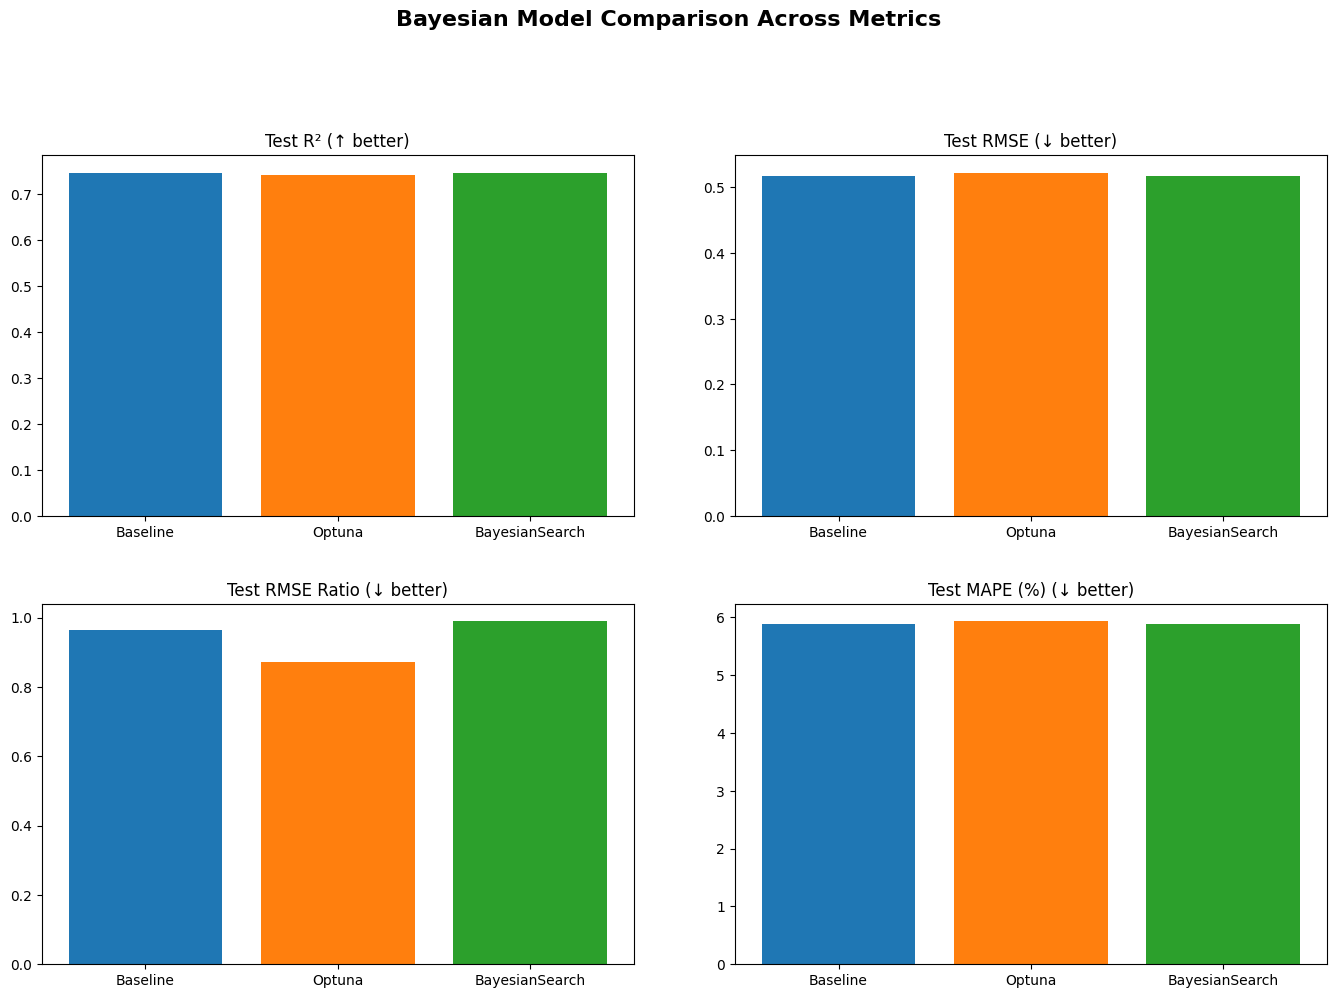

In [33]:
""" CatBoost Model Performance Comparison """

# Define metrics and titles
metrics = [
    "Test R2",
    "Test RMSE",
    "RMSE Ratio",
    "Test MAPE"
]

titles = [
    "Test R² (↑ better)",
    "Test RMSE (↓ better)",
    "Test RMSE Ratio (↓ better)",
    "Test MAPE (%) (↓ better)"
]

# Data preparation
model_labels = ["Baseline", "Optuna", "BayesianSearch"]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

values_dict = {
    "Test R2": overfit_df["Test R2"].values,
    "Test RMSE": overfit_df["Test RMSE"].values,
    "RMSE Ratio": overfit_df["RMSE Ratio"].values,
    "Test MAPE": [test_metrics_baseline[4], test_metrics_optuna[4], test_metrics_bayes[4]]
}

# Figure setup
n_metrics = len(metrics)
rows, cols = 2, 2

fig, axes = plt.subplots(rows, cols, figsize=(14, 10))
axes = axes.flatten()

# Plot each metric dynamically
for i, metric in enumerate(metrics):
    ax = axes[i]
    values = values_dict[metric]
    
    # Create horizontal bar chart with model-specific colors
    bars = ax.bar(model_labels, values, color=colors)
    
    # Title and labels
    ax.set_title(titles[i], fontsize=12)
    

# Hide any unused subplots (if any)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Add overall title and adjust layout
plt.suptitle("Bayesian Model Comparison Across Metrics", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout(pad=3.0, h_pad=3, w_pad=5)
plt.show()


# Final Summary of Model Performances

In [34]:
# final summary of all models performance
final_summary = pd.merge(performance_summary,
                    overfit_df[['Model', 'R2 Gap', 'RMSE Ratio', 'Overfitting Status', 'Model Status (Generalization)']],
                    on="Model",
                    how="outer")

In [35]:
print("Summary of The Models Performance:")
display(final_summary)

Summary of The Models Performance:


,Model,CV MSE,CV MAE,CV RMSE,CV R2,CV MAPE,Test MSE,Test MAE,Test RMSE,Test R2,Test MAPE,R2 Gap,RMSE Ratio,Overfitting Status,Model Status (Generalization)
0,CatBoost (Baseline),0.2889,0.4155,0.5375,0.7187,6.0278,0.2682,0.4002,0.5178,0.7459,5.8874,-0.0272,0.9633,Low,Good
1,CatBoost (BayesianSearch),0.2727,0.4029,0.5222,0.7345,5.8470,0.2675,0.4000,0.5172,0.7466,5.8857,-0.0121,0.9904,Low,Good
2,CatBoost (Optuna),0.3605,0.4701,0.6004,0.6489,6.7826,0.2730,0.4029,0.5225,0.7413,5.9393,-0.0924,0.8703,Mild,Good


# Persist Best Model and Performance

In [36]:
# select best variant of XGBoost model
best_idx = final_summary["Test R2"].idxmax()
best_variant = final_summary.iloc[best_idx]

In [37]:
print("Best Variation of CatBoost Model:", best_variant["Model"])

Best Variation of CatBoost Model: CatBoost (BayesianSearch)


In [38]:
# performance of best variation
best_variant = best_variant.to_frame(name='Value').rename_axis('Metrics').reset_index()

print("Performance of the best variation:")
display(best_variant)

Performance of the best variation:


,Metrics,Value
0,Model,CatBoost (BayesianSearch)
1,CV MSE,0.2727
2,CV MAE,0.4029
3,CV RMSE,0.5222
4,CV R2,0.7345
5,CV MAPE,5.847
6,Test MSE,0.2675
7,Test MAE,0.4
8,Test RMSE,0.5172
9,Test R2,0.7466


In [39]:
# model persister object
persister = ModelPersister(model_name = "CatBoost")

In [40]:
# persit all variatnt performance
persister.save_performance(performance_summary)

CatBoost performance saved: ..\artifacts\model-performance\catboostPerformance.csv


In [41]:
# persist best variant performance
persister.save_performance(best_variant, "BestVariation")

CatBoost performance saved: ..\artifacts\model-performance\catboostBestVariation.csv


In [42]:
# aggregated model performance
persister.aggregated_performance(final_summary)

Appended to aggregated performance: ..\artifacts\model-performance\a_ModelPerformance.csv


In [43]:
# save overfitting overfitting analysis
persister.append_overfitting(overfit_df)

Appended to overfitting analysis: ..\artifacts\model-performance\a_overfittingAnalysis.csv


In [44]:
# save the best variant of XGBoost model
persister.save_model(bayesSearch_model)

Model saved: ..\artifacts\models/catboost.pkl
